# 05 — Walidacja: statystyki modeli (TRAIN vs TEST)

Podstawowe metryki **wszystkich modeli** na zbiorze treningowym (`train_fit`) i testowym
(`holdout 40%`): **Accuracy, ROC-AUC, Precision, Recall, F1** — w dwóch ujęciach:

1. **Średnie** (weighted avg — uwzględnia liczebność klas),
2. **Per klasa attrition**: **Zostaje (0)** i **Rezygnuje (1)**.

Notebook jest **samowystarczalny** — wszystkie statystyki liczone są bezpośrednio tutaj
(sklearn), bez importów z `src/` ani `scripts/`. Wczytuje surowe dane `data/raw/HR.csv`
oraz gotowe pipeline'y `models/*.joblib` (są samowystarczalne — przyjmują surowe dane).
**CatBoost pominięty.**

## 0. Import i konfiguracja

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
)

# Stałe identyczne jak w config.py (powtórzony podział train/val/test)
RANDOM_STATE, TEST_SIZE, VAL_SIZE = 42, 0.4, 0.2

ROOT = Path('..').resolve()
import sys
# src/ na sciezce TYLKO po to, by joblib odtworzyl klasy pipeline (ThresholdClassifier,
# FeatureEngineeringTransformer itd.) przy wczytaniu .joblib — statystyki liczymy inline ponizej.
sys.path.insert(0, str(ROOT / 'src'))

_LABELS = {
    'baseline':            'Baseline',
    'logistic_regression': 'Logistic Regression',
    'svm':                 'SVM',
    'voting_lr_svm':       'Voting LR+SVM',
    'voting':              'Voting LR+SVM+MLP',
    'neural_network':      'MLP (sklearn)',
    'tf_neural_network':   'TF Neural Network',
    'random_forest':       'Random Forest',
    'balanced_rf':         'Balanced RF',
    'xgboost':             'XGBoost',
    'stacking':            'Stacking (LR+SVM->LR)',
}

def label(name):
    if name.endswith('_top10'):
        return _LABELS.get(name[:-6], name[:-6]) + ' (top10)'
    return _LABELS.get(name, name)


## 1. Dane i modele

Surowe dane `HR.csv` → podział `train_fit` (48%) / `val` (12%) / `test` (40%) z tym samym
`RANDOM_STATE`, więc partycje są identyczne jak w treningu.
**TRAIN** = `train_fit`, **TEST** = `holdout`. Modele z `catboost` są pomijane.

In [2]:
df = pd.read_csv(ROOT / 'data' / 'raw' / 'HR.csv')
y = df['Attrition'].astype(int)
X = df.drop(columns=['Attrition'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train)

SPLITS = [('TRAIN', X_train_fit, y_train_fit), ('TEST', X_test, y_test)]

_SKIP = {'metadata', 'best_model', 'preprocessing_pipeline', 'ensemble'}
pipelines = {}
for path in sorted((ROOT / 'models').glob('*.joblib')):
    if path.stem in _SKIP or 'catboost' in path.stem:
        continue
    pipelines[path.stem] = joblib.load(path)

print(f'Wczytano modeli: {len(pipelines)} (CatBoost pominiety)')
for sname, Xs, ys in SPLITS:
    n1 = int((ys == 1).sum())
    print(f'  {sname}: {len(ys)} probek  |  Rezygnuje(1)={n1} ({n1/len(ys):.1%})  |  Zostaje(0)={len(ys)-n1}')


Wczytano modeli: 20 (CatBoost pominiety)
  TRAIN: 705 probek  |  Rezygnuje(1)=114 (16.2%)  |  Zostaje(0)=591
  TEST: 588 probek  |  Rezygnuje(1)=95 (16.2%)  |  Zostaje(0)=493


## 2. Statystyki średnie (weighted) — TRAIN vs TEST

Dla każdego modelu i zbioru: **Accuracy, ROC-AUC, Precision, Recall, F1** (średnia ważona).
Sortowanie wg F1 na TEST.

In [3]:
def avg_stats(pipelines, splits, average='weighted'):
    rows = []
    for name, pipe in pipelines.items():
        rec = {'Model': label(name)}
        for sname, Xs, ys in splits:
            y_pred = pipe.predict(Xs)
            y_proba = pipe.predict_proba(Xs)[:, 1]
            rec[f'Accuracy_{sname}']  = round(accuracy_score(ys, y_pred), 4)
            rec[f'AUC_{sname}']       = round(roc_auc_score(ys, y_proba), 4)
            rec[f'Precision_{sname}'] = round(precision_score(ys, y_pred, average=average, zero_division=0), 4)
            rec[f'Recall_{sname}']    = round(recall_score(ys, y_pred, average=average, zero_division=0), 4)
            rec[f'F1_{sname}']        = round(f1_score(ys, y_pred, average=average, zero_division=0), 4)
        rows.append(rec)
    cols = ['Model'] + [f'{m}_{s}' for s in ['TRAIN', 'TEST']
                        for m in ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']]
    return pd.DataFrame(rows)[cols].set_index('Model').sort_values('F1_TEST', ascending=False)

means = avg_stats(pipelines, SPLITS)
print('Najlepszy F1 (weighted) na TEST:', means['F1_TEST'].idxmax(), '=', means['F1_TEST'].max())

means.style \
    .background_gradient(subset=['F1_TEST', 'F1_TRAIN'], cmap='RdYlGn', vmin=0.4, vmax=1.0) \
    .background_gradient(subset=['AUC_TEST'], cmap='Oranges', vmin=0.5, vmax=0.85) \
    .format(precision=4)


Najlepszy F1 (weighted) na TEST: Logistic Regression = 0.8716


,Accuracy_TRAIN,AUC_TRAIN,Precision_TRAIN,Recall_TRAIN,F1_TRAIN,Accuracy_TEST,AUC_TEST,Precision_TEST,Recall_TEST,F1_TEST
Model,,,,,,,,,,
Logistic Regression,0.8979,0.8976,0.8965,0.8979,0.8971,0.8724,0.8210,0.8709,0.8724,0.8716
Voting LR+SVM,0.8809,0.8977,0.8903,0.8809,0.8846,0.8588,0.8181,0.8684,0.8588,0.8629
SVM,0.8794,0.8956,0.8874,0.8794,0.8827,0.8486,0.8138,0.8587,0.8486,0.8530
Voting LR+SVM+MLP,0.8993,0.9206,0.9028,0.8993,0.9008,0.8469,0.8157,0.8564,0.8469,0.8511
XGBoost,0.9489,0.9806,0.9476,0.9489,0.9476,0.8503,0.8046,0.8343,0.8503,0.8395
Balanced RF (top10),0.8738,0.8900,0.8831,0.8738,0.8776,0.8299,0.7831,0.8418,0.8299,0.8351
Balanced RF,0.8823,0.9030,0.8964,0.8823,0.8874,0.8129,0.7904,0.8371,0.8129,0.8227
Random Forest,0.8709,0.9004,0.8871,0.8709,0.8769,0.8095,0.7893,0.8373,0.8095,0.8206
TF Neural Network (top10),0.9404,0.9692,0.9424,0.9404,0.9354,0.8367,0.6903,0.8047,0.8367,0.8115


## 3. Statystyki per klasa attrition (0, 1)

**Precision, Recall, F1** osobno dla każdej klasy, na TRAIN i TEST.
(Accuracy i ROC-AUC są miarami całościowymi — patrz sekcja 2.)

In [4]:
def class_stats(pipelines, splits, pos_label):
    rows = []
    for name, pipe in pipelines.items():
        rec = {'Model': label(name)}
        for sname, Xs, ys in splits:
            y_pred = pipe.predict(Xs)
            rec[f'Precision_{sname}'] = round(precision_score(ys, y_pred, pos_label=pos_label, zero_division=0), 4)
            rec[f'Recall_{sname}']    = round(recall_score(ys, y_pred, pos_label=pos_label, zero_division=0), 4)
            rec[f'F1_{sname}']        = round(f1_score(ys, y_pred, pos_label=pos_label, zero_division=0), 4)
        rows.append(rec)
    cols = ['Model'] + [f'{m}_{s}' for s in ['TRAIN', 'TEST']
                        for m in ['Precision', 'Recall', 'F1']]
    return pd.DataFrame(rows)[cols].set_index('Model').sort_values('F1_TEST', ascending=False)


### 3a. Klasa **Rezygnuje (1)** — kluczowa dla biznesu

In [5]:
resign = class_stats(pipelines, SPLITS, pos_label=1)
resign.style \
    .background_gradient(subset=['F1_TEST'], cmap='RdYlGn', vmin=0, vmax=0.65) \
    .background_gradient(subset=['Precision_TEST', 'Recall_TEST'], cmap='Blues', vmin=0, vmax=0.8) \
    .background_gradient(subset=['F1_TRAIN'], cmap='RdYlGn', vmin=0, vmax=0.9) \
    .format(precision=4)


,Precision_TRAIN,Recall_TRAIN,F1_TRAIN,Precision_TEST,Recall_TEST,F1_TEST
Model,,,,,,
Logistic Regression,0.6909,0.6667,0.6786,0.6087,0.5895,0.5989
Voting LR+SVM,0.6119,0.7193,0.6613,0.5545,0.6421,0.5951
SVM,0.6107,0.7018,0.6531,0.5273,0.6105,0.5659
Voting LR+SVM+MLP,0.6748,0.7281,0.7004,0.5229,0.6000,0.5588
Balanced RF (top10),0.5940,0.6930,0.6397,0.4775,0.5579,0.5146
Balanced RF,0.6084,0.7632,0.6770,0.4400,0.5789,0.5000
Random Forest,0.5793,0.7368,0.6486,0.4341,0.5895,0.5000
MLP (sklearn),0.6135,0.8772,0.7220,0.3974,0.6526,0.4940
Logistic Regression (top10),0.5380,0.7456,0.6250,0.4085,0.6105,0.4895


### 3b. Klasa **Zostaje (0)** — kontekst

In [6]:
stay = class_stats(pipelines, SPLITS, pos_label=0)
stay.style \
    .background_gradient(subset=['F1_TEST', 'F1_TRAIN'], cmap='RdYlGn', vmin=0.8, vmax=1.0) \
    .background_gradient(subset=['Precision_TEST', 'Recall_TEST'], cmap='Blues', vmin=0.8, vmax=1.0) \
    .format(precision=4)


,Precision_TRAIN,Recall_TRAIN,F1_TRAIN,Precision_TEST,Recall_TEST,F1_TEST
Model,,,,,,
Logistic Regression,0.9361,0.9425,0.9393,0.9214,0.9270,0.9242
Voting LR+SVM,0.9440,0.9120,0.9277,0.9289,0.9006,0.9145
XGBoost,0.9587,0.9814,0.9699,0.8887,0.9391,0.9132
Baseline,0.8383,1.0000,0.9120,0.8384,1.0000,0.9121
SVM,0.9408,0.9137,0.9270,0.9226,0.8945,0.9083
Voting LR+SVM+MLP,0.9467,0.9323,0.9395,0.9207,0.8945,0.9074
TF Neural Network (top10),0.9364,0.9966,0.9656,0.8656,0.9533,0.9073
Balanced RF (top10),0.9388,0.9086,0.9235,0.9119,0.8824,0.8969
Balanced RF,0.9520,0.9052,0.9280,0.9136,0.8580,0.8849


## 4. Wizualizacja — F1 per klasa na TEST i TRAIN vs TEST

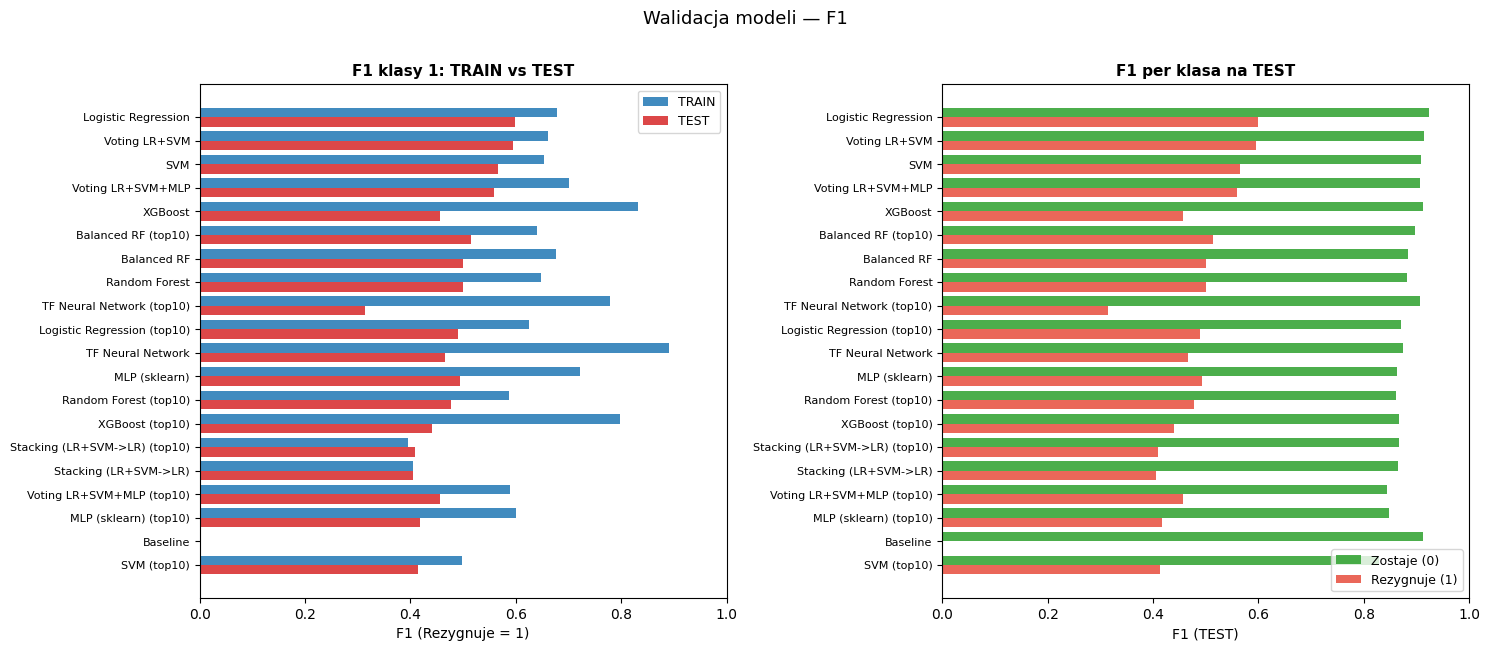

In [7]:
order = means.index.tolist()
yy = np.arange(len(order))

f1_tr_1 = resign['F1_TRAIN'].reindex(order)
f1_te_1 = resign['F1_TEST'].reindex(order)
f1_te_0 = stay['F1_TEST'].reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(order) * 0.32)))

axes[0].barh(yy - 0.2, f1_tr_1.values, 0.4, label='TRAIN', color='#1f77b4', alpha=0.85)
axes[0].barh(yy + 0.2, f1_te_1.values, 0.4, label='TEST',  color='#d62728', alpha=0.85)
axes[0].set_yticks(yy); axes[0].set_yticklabels(order, fontsize=8); axes[0].invert_yaxis()
axes[0].set_xlabel('F1 (Rezygnuje = 1)'); axes[0].set_xlim(0, 1.0)
axes[0].set_title('F1 klasy 1: TRAIN vs TEST', fontsize=11, fontweight='bold'); axes[0].legend(fontsize=9)

axes[1].barh(yy - 0.2, f1_te_0.values, 0.4, label='Zostaje (0)',   color='#2ca02c', alpha=0.85)
axes[1].barh(yy + 0.2, f1_te_1.values, 0.4, label='Rezygnuje (1)', color='#e74c3c', alpha=0.85)
axes[1].set_yticks(yy); axes[1].set_yticklabels(order, fontsize=8); axes[1].invert_yaxis()
axes[1].set_xlabel('F1 (TEST)'); axes[1].set_xlim(0, 1.0)
axes[1].set_title('F1 per klasa na TEST', fontsize=11, fontweight='bold'); axes[1].legend(fontsize=9)

fig.suptitle('Walidacja modeli — F1', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. Wnioski

- **Klasa 0 (Zostaje)** osiąga F1 ~0.88–0.92, **klasa 1 (Rezygnuje)** tylko ~0.5–0.6 —
  to efekt niezbalansowania (~16% odejść), nie braku sygnału (ROC-AUC ~0.80–0.82).
- Średnie **ważone** są wysokie (~0.85+), bo dominuje klasa 0 — dlatego do oceny jakości
  liczy się przede wszystkim **F1/Recall klasy Rezygnuje (1)**.
- Duża różnica F1 TRAIN vs TEST (zwłaszcza dla drzew i sieci) sygnalizuje overfitting;
  modele liniowe (LR, SVM) i ich **voting** generalizują najlepiej.